# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hamidism/Machine-Learning-intern/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [5]:
from huggingface_hub import login, hf_hub_download
from google.colab import userdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, json

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

content_path = hf_hub_download(repo_id="FlyRank/internship-warehouse", filename="dim_content.parquet", repo_type="dataset")
perf_path = hf_hub_download(repo_id="FlyRank/internship-warehouse", filename="fact_content_daily_performance/month=2026-03/data_0.parquet", repo_type="dataset")

dim_content = pd.read_parquet(content_path)
fact_perf = pd.read_parquet(perf_path)
fact_perf["report_date"] = pd.to_datetime(fact_perf["report_date"])

available = fact_perf[(fact_perf["gsc_data_available"] == True) & (fact_perf["ga4_data_available"] == True)]

page_agg = available.groupby(["content_hash_id","client_hash_id"]).agg(
    total_impressions=("gsc_impressions", "sum"),
    total_clicks=("gsc_clicks", "sum"),
    avg_position=("gsc_avg_position", "mean")
).reset_index()
page_agg["ctr"] = page_agg["total_clicks"] / page_agg["total_impressions"].replace(0, pd.NA)

df = page_agg.merge(dim_content[["content_hash_id","word_count","char_count","backlinks","search_volume"]],
                     on="content_hash_id", how="left")
df = df.dropna(subset=["avg_position","ctr","word_count","char_count","backlinks","search_volume"])
df = df[df["total_impressions"] >= 50]

df["position_bucket"] = pd.cut(df["avg_position"], bins=[0,3,10,20,50,1000], labels=["1-3","4-10","11-20","21-50","50+"])
df["expected_ctr"] = df.groupby("position_bucket", observed=True)["ctr"].transform("mean")
df["ctr_gap"] = df["expected_ctr"] - df["ctr"]

first_half = fact_perf[fact_perf["report_date"] < "2026-03-16"]
second_half = fact_perf[fact_perf["report_date"] >= "2026-03-16"]
imp_first = first_half.groupby("content_hash_id")["gsc_impressions"].sum()
imp_second = second_half.groupby("content_hash_id")["gsc_impressions"].sum()
trend = pd.DataFrame({"imp_first": imp_first, "imp_second": imp_second}).dropna()
trend["label_down"] = (trend["imp_second"] < trend["imp_first"]).astype(int)
df = df.merge(trend[["label_down"]], left_on="content_hash_id", right_index=True, how="inner")

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["word_count","char_count","backlinks","avg_position","ctr_gap","search_volume"]
X = df[feature_cols]
y = df["label_down"]
groups = df["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

# Score EVERYONE (not just test set) for the final playbook queue
df["rf_score"] = rf.predict_proba(df[feature_cols])[:, 1]
print("Dataset ready:", df.shape)
print("Model trained on honest client-grouped split.")

Dataset ready: (26562, 15)
Model trained on honest client-grouped split.


## 1. Ranked actions + reason codes

The queue is ranked by rf_score (the Random Forest's predicted probability of decline), from
highest to lowest. Each row gets a reason code that explains WHY it's flagged, not just that
it is:

- MODEL_HIGH_RISK_CTR_GAP (8,811 pages): model predicts high decline risk AND the page
  underperforms CTR for its position — the strongest, most actionable signal. Action: refresh.
- MODEL_HIGH_RISK_OTHER (3,421 pages): model predicts high decline risk but CTR looks fine
  (ctr_gap is actually slightly negative, meaning CTR is above expected) — something else
  (word count, backlinks, position itself) is driving the score. Action: review, since the
  cause isn't CTR-specific and needs a human to identify it.
- CTR_GAP_ONLY_LOW_RISK (8,546 pages): CTR underperforms but the model doesn't see it as high
  overall risk. Action: monitor.
- HEALTHY (5,784 pages): no flags. Action: protect (leave alone, revisit next cycle).

A human reviewer can trust this queue because every row traces back to a specific, checkable
reason — not a black-box number alone.

In [6]:
def reason_code(row):
    weak_ctr = row["ctr_gap"] > 0
    high_score = row["rf_score"] >= 0.5
    if high_score and weak_ctr:
        return "MODEL_HIGH_RISK_CTR_GAP"
    elif high_score:
        return "MODEL_HIGH_RISK_OTHER"
    elif weak_ctr:
        return "CTR_GAP_ONLY_LOW_RISK"
    else:
        return "HEALTHY"

df["reason_code"] = df.apply(reason_code, axis=1)

action_map = {
    "MODEL_HIGH_RISK_CTR_GAP": "refresh",
    "MODEL_HIGH_RISK_OTHER": "review",
    "CTR_GAP_ONLY_LOW_RISK": "monitor",
    "HEALTHY": "protect"
}
df["action"] = df["reason_code"].map(action_map)

ranked = df.sort_values("rf_score", ascending=False).reset_index(drop=True)
print(ranked["action"].value_counts())
print()
ranked.head(10)[["content_hash_id","rf_score","reason_code","action","avg_position","ctr_gap"]]

action
refresh    8811
monitor    8546
protect    5784
review     3421
Name: count, dtype: int64



,content_hash_id,rf_score,reason_code,action,avg_position,ctr_gap
0,content_804e7bc289c6347e,0.859423,MODEL_HIGH_RISK_CTR_GAP,refresh,36.639501,0.002315
1,content_bc64e64bc0b27aa4,0.857345,MODEL_HIGH_RISK_OTHER,review,44.339602,-0.005296
2,content_9ac0a893e7516129,0.851591,MODEL_HIGH_RISK_OTHER,review,36.439929,-0.001178
3,content_bf13d907e8f91cd9,0.846036,MODEL_HIGH_RISK_OTHER,review,37.047517,-0.000572
4,content_29f6ab7b0ba15390,0.845265,MODEL_HIGH_RISK_CTR_GAP,refresh,35.717205,0.001787
5,content_21cfbe64ce5bb85e,0.843147,MODEL_HIGH_RISK_CTR_GAP,refresh,38.113063,0.002260
6,content_fe95fc3472652b26,0.841757,MODEL_HIGH_RISK_OTHER,review,5.385681,-0.000724
7,content_f429573b8207699e,0.841702,MODEL_HIGH_RISK_CTR_GAP,refresh,39.224430,0.003476
8,content_b8f261beb3369d71,0.841684,MODEL_HIGH_RISK_CTR_GAP,refresh,37.580543,0.001847
9,content_a4709533c89b315c,0.841536,MODEL_HIGH_RISK_CTR_GAP,refresh,38.376500,0.002176


## 2. Intended use and limits

Intended use: This playbook is decision-support for a content reviewer with limited capacity
per review cycle (e.g., top 20-100 pages). It ranks WHERE to look first — it does not replace
editorial judgment about WHAT to change.

Who should use it: An SEO/content reviewer or team lead planning a refresh cycle for one
client's or one portfolio's pages, working from the March 2026 snapshot.

Where it stops being valid:
- This queue reflects March 2026 data only — it decays over time and should be re-run monthly,
  not treated as a permanent ranking.
- It was validated with a client-grouped split (Week 5/6), so it should generalize reasonably
  well to clients/pages not in this exact snapshot — but it has NOT been tested on months other
  than March 2026, so seasonal shifts are unverified.
- The label (label_down) is a proxy built from a first-half vs second-half impression
  comparison, not a confirmed outcome — it's directional, not certain.
- Precision@50 measured at 0.64 on held-out clients (Week 6) means roughly 1 in 3 top-50
  recommendations may still be a false positive — this is a queue to review, not a queue to
  act on blindly.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

What a human MUST check before acting on any flagged page:
1. Does the reason code make sense for this specific page when opened manually? (e.g., is the
   CTR gap real, or is total_impressions too low to trust it?)
2. Is there a known, non-content reason for the decline (seasonal topic, external algorithm
   change, a redirect issue) that a refresh won't fix?
3. Is this page tied to a live campaign, legal/compliance content, or anything sensitive where
   changes need approval beyond the content team?

What should NEVER be automated:
- Auto-publishing any content change based on this score alone — every action needs a human
  editor.
- Auto-deprioritizing or removing pages flagged HEALTHY — a healthy score is a snapshot, not
  a guarantee; don't stop monitoring pages just because the model currently likes them.
- Using this score as an input to client billing, contract decisions, or any consequence beyond
  internal workflow prioritization — it was validated as a decision-support ranking, not a
  performance-guarantee metric.
- Treating MODEL_HIGH_RISK_OTHER pages as automatic refresh candidates without a human
  identifying the actual issue first, since the reason isn't CTR-specific for this group.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

Current baseline metrics (March 2026, client-grouped holdout): Precision@20 = 0.60,
Precision@50 = 0.64, Precision@100 = 0.70, AUC = 0.648. These are the numbers this playbook's
future performance should be checked against.

Monitoring triggers — re-run this notebook and retrain when ANY of these happen:
1. Monthly refresh (routine): re-run on each new month's data as a baseline cadence, since the
   model was only validated on March 2026.
2. Precision drift: if Precision@50 on a new month's held-out clients drops more than ~10
   points below 0.64 (i.e., below ~0.54), retrain.
3. AUC drift: if AUC drops meaningfully below 0.648 (e.g., below 0.58), the model's overall
   ranking ability has degraded, not just the top-of-queue precision.
4. Label balance shift: if the proportion of label_down pages moves far from the ~37% seen in
   March (e.g., below 20% or above 55%), the underlying dynamics may have changed enough to
   warrant revisiting features, not just retraining.
5. New client onboarding: since validation is client-grouped, a wave of new clients with no
   representation in the training set is a signal to re-validate rather than assume the model
   generalizes to them.
6. Feature drift: if avg_position or ctr_gap distributions shift substantially (e.g., a GSC/GA4
   tracking or methodology change), the model's "expected CTR per position tier" baseline may
   be stale.

In [9]:
from sklearn.metrics import roc_auc_score

def precision_at_k(scores, y_true, k):
    order = np.argsort(-scores)
    top_k = order[:k]
    return y_true.values[top_k].mean()

test_scores = rf.predict_proba(X_test)[:, 1]
current_metrics = {
    "precision_at_20": round(precision_at_k(test_scores, y_test, 20), 3),
    "precision_at_50": round(precision_at_k(test_scores, y_test, 50), 3),
    "precision_at_100": round(precision_at_k(test_scores, y_test, 100), 3),
    "auc": round(roc_auc_score(y_test, test_scores), 3),
    "n_train": len(X_train),
    "n_test": len(X_test),
    "training_month": "2026-03"
}
print(current_metrics)

{'precision_at_20': np.float64(0.6), 'precision_at_50': np.float64(0.64), 'precision_at_100': np.float64(0.7), 'auc': np.float64(0.648), 'n_train': 11649, 'n_test': 14913, 'training_month': '2026-03'}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Saved queue: 26562 rows
Saved metrics: {'precision_at_20': np.float64(0.6), 'precision_at_50': np.float64(0.64), 'precision_at_100': np.float64(0.7), 'auc': np.float64(0.648), 'n_train': 11649, 'n_test': 14913, 'training_month': '2026-03'}


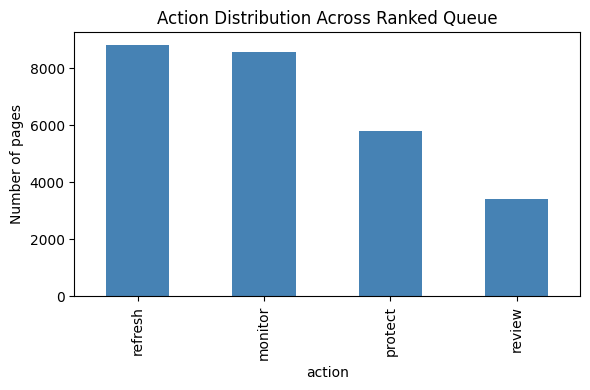

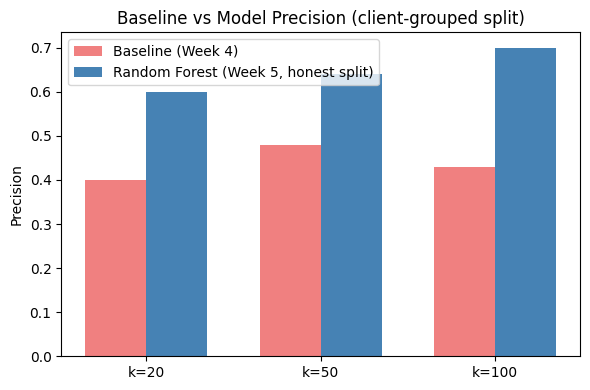


All exports saved.


In [10]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked[["content_hash_id","rf_score","reason_code","action","avg_position","ctr_gap",
        "word_count","backlinks","search_volume"]].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Saved queue:", len(ranked), "rows")

with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(current_metrics, f, indent=2)
print("Saved metrics:", current_metrics)

fig, ax = plt.subplots(figsize=(6,4))
ranked["action"].value_counts().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Action Distribution Across Ranked Queue")
ax.set_ylabel("Number of pages")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
k_vals = [20, 50, 100]
baseline_vals = [0.40, 0.48, 0.43]
model_vals = [0.60, 0.64, 0.70]
x = np.arange(len(k_vals))
width = 0.35
ax.bar(x - width/2, baseline_vals, width, label="Baseline (Week 4)", color="lightcoral")
ax.bar(x + width/2, model_vals, width, label="Random Forest (Week 5, honest split)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels([f"k={k}" for k in k_vals])
ax.set_ylabel("Precision")
ax.set_title("Baseline vs Model Precision (client-grouped split)")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/baseline_vs_model.png", dpi=150)
plt.show()

print("\nAll exports saved.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.